# Exploratory Data Analysis - NSL-KDD Dataset
This notebook performs Phase 1 Exploratory Data Analysis (EDA) on the NSL-KDD dataset. 

### Goals:
1. Verify record counts and dimensions for training and test datasets.
2. Check for missing values.
3. Analyze normal vs. attack distribution.
4. Map specific attack types to their 4 high-level categories (DoS, Probe, R2L, U2R) and analyze their distribution.
5. Extract key insights to guide preprocessing and modeling in subsequent phases.


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual styles
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

print("Libraries imported and visualization styles configured.")


Matplotlib is building the font cache; this may take a moment.


Libraries imported and visualization styles configured.


In [2]:
# Define column names based on the NSL-KDD specifications
column_names = [
    "duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes", 
    "land", "wrong_fragment", "urgent", "hot", "num_failed_logins", 
    "logged_in", "num_compromised", "root_shell", "su_attempted", 
    "num_root", "num_file_creations", "num_shells", "num_access_files", 
    "num_outbound_cmds", "is_host_login", "is_guest_login", "count", 
    "srv_count", "serror_rate", "srv_serror_rate", "rerror_rate", 
    "srv_rerror_rate", "same_srv_rate", "diff_srv_rate", "srv_diff_host_rate", 
    "dst_host_count", "dst_host_srv_count", "dst_host_same_srv_rate", 
    "dst_host_diff_srv_rate", "dst_host_same_src_port_rate", 
    "dst_host_srv_diff_host_rate", "dst_host_serror_rate", 
    "dst_host_srv_serror_rate", "dst_host_rerror_rate", 
    "dst_host_srv_rerror_rate", "label", "difficulty_level"
]

# Relative paths to the data files
train_path = os.path.join("..", "data", "raw", "KDDTrain+.txt")
test_path = os.path.join("..", "data", "raw", "KDDTest+.txt")

# Load datasets
train_df = pd.read_csv(train_path, names=column_names)
test_df = pd.read_csv(test_path, names=column_names)

print(f"Loaded KDDTrain+ with shape: {train_df.shape}")
print(f"Loaded KDDTest+ with shape: {test_df.shape}")


Loaded KDDTrain+ with shape: (125973, 43)
Loaded KDDTest+ with shape: (22544, 43)


### 1. Dataset Dimensions & Basic Summary
We verify the number of records, features, and inspect the first few rows of the training set.


In [3]:
print("=== Training Data Information ===")
train_df.info()

print("\n=== Testing Data Information ===")
test_df.info()


=== Training Data Information ===
<class 'pandas.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125973 non-null  int64  
 1   protocol_type                125973 non-null  str    
 2   service                      125973 non-null  str    
 3   flag                         125973 non-null  str    
 4   src_bytes                    125973 non-null  int64  
 5   dst_bytes                    125973 non-null  int64  
 6   land                         125973 non-null  int64  
 7   wrong_fragment               125973 non-null  int64  
 8   urgent                       125973 non-null  int64  
 9   hot                          125973 non-null  int64  
 10  num_failed_logins            125973 non-null  int64  
 11  logged_in                    125973 non-null  int64  
 12  num_compromised              125973

In [4]:
# Display the first few rows of the training set
train_df.head()


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty_level
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


### 2. Missing Values Check
We will check if there are any missing or null values in both datasets.


In [5]:
train_missing = train_df.isnull().sum().sum()
test_missing = test_df.isnull().sum().sum()

print(f"Total missing values in Training Set: {train_missing}")
print(f"Total missing values in Testing Set: {test_missing}")

if train_missing > 0:
    print("Columns with missing values in Training Set:")
    print(train_df.isnull().sum()[train_df.isnull().sum() > 0])


Total missing values in Training Set: 0
Total missing values in Testing Set: 0


### 3. Normal vs. Attack Distribution
Let's analyze the distribution of Normal traffic vs. Attack traffic. The `label` column specifies the exact traffic type. If it is `'normal'`, it's benign; otherwise, it represents an attack.



=== Train Set Distribution ===
Normal: 67343 (53.46%)
Attack: 58630 (46.54%)

=== Test Set Distribution ===
Attack: 12833 (56.92%)
Normal: 9711 (43.08%)


C:\Users\admin\AppData\Local\Temp\ipykernel_18440\1377084516.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='is_attack', data=df, ax=axes[i], order=['normal', 'attack'], palette=colors)


C:\Users\admin\AppData\Local\Temp\ipykernel_18440\1377084516.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='is_attack', data=df, ax=axes[i], order=['normal', 'attack'], palette=colors)


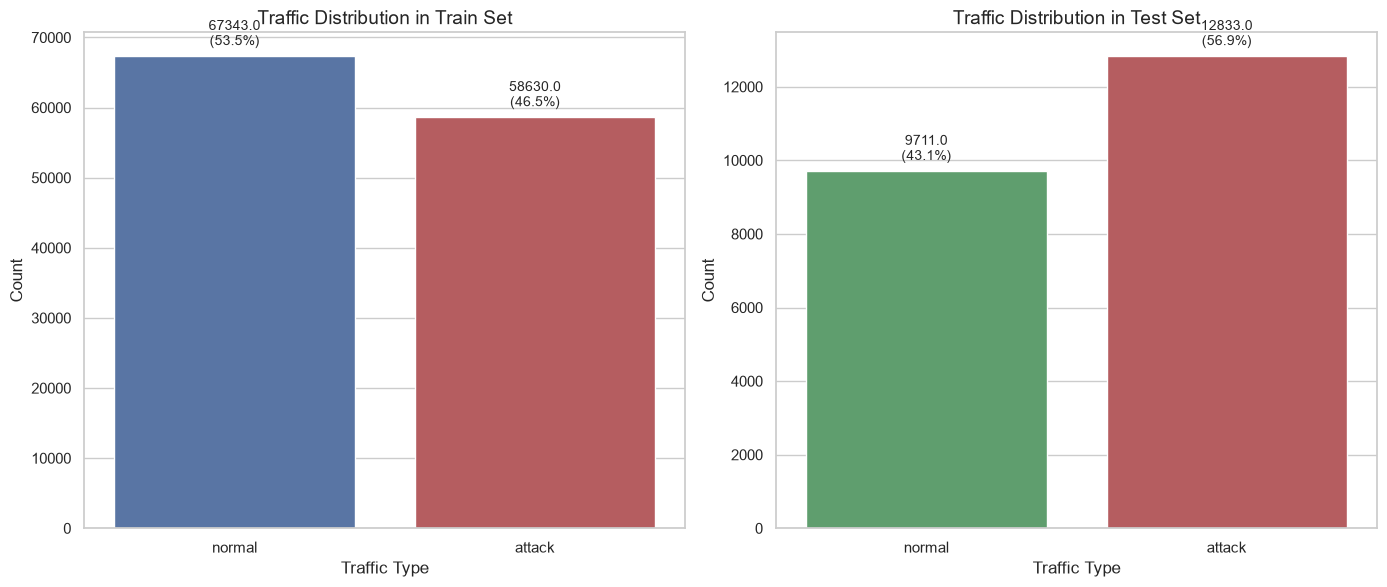

In [6]:
# Create a binary target indicator 'is_attack'
train_df['is_attack'] = train_df['label'].apply(lambda x: 'normal' if x == 'normal' else 'attack')
test_df['is_attack'] = test_df['label'].apply(lambda x: 'normal' if x == 'normal' else 'attack')

# Value counts and percentages
for name, df in [('Train', train_df), ('Test', test_df)]:
    counts = df['is_attack'].value_counts()
    pcts = df['is_attack'].value_counts(normalize=True) * 100
    print(f"\n=== {name} Set Distribution ===")
    for idx in counts.index:
        print(f"{idx.capitalize()}: {counts[idx]} ({pcts[idx]:.2f}%)")

# Plot distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for i, (name, df) in enumerate([('Train Set', train_df), ('Test Set', test_df)]):
    colors = ['#4c72b0', '#c44e52'] if name == 'Train Set' else ['#55a868', '#c44e52']
    sns.countplot(x='is_attack', data=df, ax=axes[i], order=['normal', 'attack'], palette=colors)
    axes[i].set_title(f"Traffic Distribution in {name}")
    axes[i].set_xlabel("Traffic Type")
    axes[i].set_ylabel("Count")
    
    # Add count and percent text labels above bars
    for p in axes[i].patches:
        height = p.get_height()
        percentage = (height / len(df)) * 100
        axes[i].annotate(f'{height}\n({percentage:.1f}%)',
                    xy=(p.get_x() + p.get_width() / 2, height),
                    xytext=(0, 5),  # 5 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()


### 4. Detailed Attack Categories Mapping
The NSL-KDD dataset has many individual attack types. These are typically grouped into four main categories:
1. **DoS (Denial of Service)**: Resource exhaustion (e.g., neptune, smurf, back).
2. **Probe**: Port scanning, network mapping (e.g., satan, ipsweep, nmap).
3. **R2L (Remote to Local)**: Unauthorized remote access (e.g., guess_passwd, warezclient).
4. **U2R (User to Root)**: Privilege escalation (e.g., buffer_overflow, rootkit).

Let's define a mapping to group these attack labels.


In [7]:
# Detailed mapping of attack types to high-level categories
attack_mapping = {
    # DoS attacks
    'back': 'dos',
    'land': 'dos',
    'neptune': 'dos',
    'pod': 'dos',
    'smurf': 'dos',
    'teardrop': 'dos',
    'apache2': 'dos',
    'udpstorm': 'dos',
    'processtable': 'dos',
    'worm': 'dos',
    'mailbomb': 'dos',
    
    # Probe attacks
    'satan': 'probe',
    'ipsweep': 'probe',
    'nmap': 'probe',
    'portsweep': 'probe',
    'mscan': 'probe',
    'saint': 'probe',
    
    # R2L attacks
    'guess_passwd': 'r2l',
    'ftp_write': 'r2l',
    'imap': 'r2l',
    'phf': 'r2l',
    'multihop': 'r2l',
    'warezmaster': 'r2l',
    'warezclient': 'r2l',
    'spy': 'r2l',
    'xlock': 'r2l',
    'xsnoop': 'r2l',
    'snmpguess': 'r2l',
    'snmpgetattack': 'r2l',
    'httptunnel': 'r2l',
    'sendmail': 'r2l',
    'named': 'r2l',
    
    # U2R attacks
    'buffer_overflow': 'u2r',
    'loadmodule': 'u2r',
    'rootkit': 'u2r',
    'perl': 'u2r',
    'sqlattack': 'u2r',
    'xterm': 'u2r',
    'ps': 'u2r',
}

def map_attack_category(label):
    label_clean = label.strip().lower()
    if label_clean == 'normal':
        return 'normal'
    return attack_mapping.get(label_clean, 'unknown')

# Apply mapping
train_df['attack_category'] = train_df['label'].apply(map_attack_category)
test_df['attack_category'] = test_df['label'].apply(map_attack_category)

# Verify if there are any unknown mappings
unknown_train = train_df[train_df['attack_category'] == 'unknown']['label'].unique()
unknown_test = test_df[test_df['attack_category'] == 'unknown']['label'].unique()

print(f"Unknown attack mappings in Train: {unknown_train}")
print(f"Unknown attack mappings in Test: {unknown_test}")


Unknown attack mappings in Train: <StringArray>
[]
Length: 0, dtype: str
Unknown attack mappings in Test: <StringArray>
[]
Length: 0, dtype: str


### 5. Attack Category Distribution
Let's analyze the distribution of the mapped attack categories (normal, dos, probe, r2l, u2r).



=== Train Attack Category Distribution ===
NORMAL: 67343 (53.46%)
DOS: 45927 (36.46%)
PROBE: 11656 (9.25%)
R2L: 995 (0.79%)
U2R: 52 (0.04%)

=== Test Attack Category Distribution ===
NORMAL: 9711 (43.08%)
DOS: 7460 (33.09%)
R2L: 2885 (12.80%)
PROBE: 2421 (10.74%)
U2R: 67 (0.30%)


C:\Users\admin\AppData\Local\Temp\ipykernel_18440\3437052357.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='attack_category', data=df, ax=axes[i], order=order, palette="viridis")


C:\Users\admin\AppData\Local\Temp\ipykernel_18440\3437052357.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='attack_category', data=df, ax=axes[i], order=order, palette="viridis")


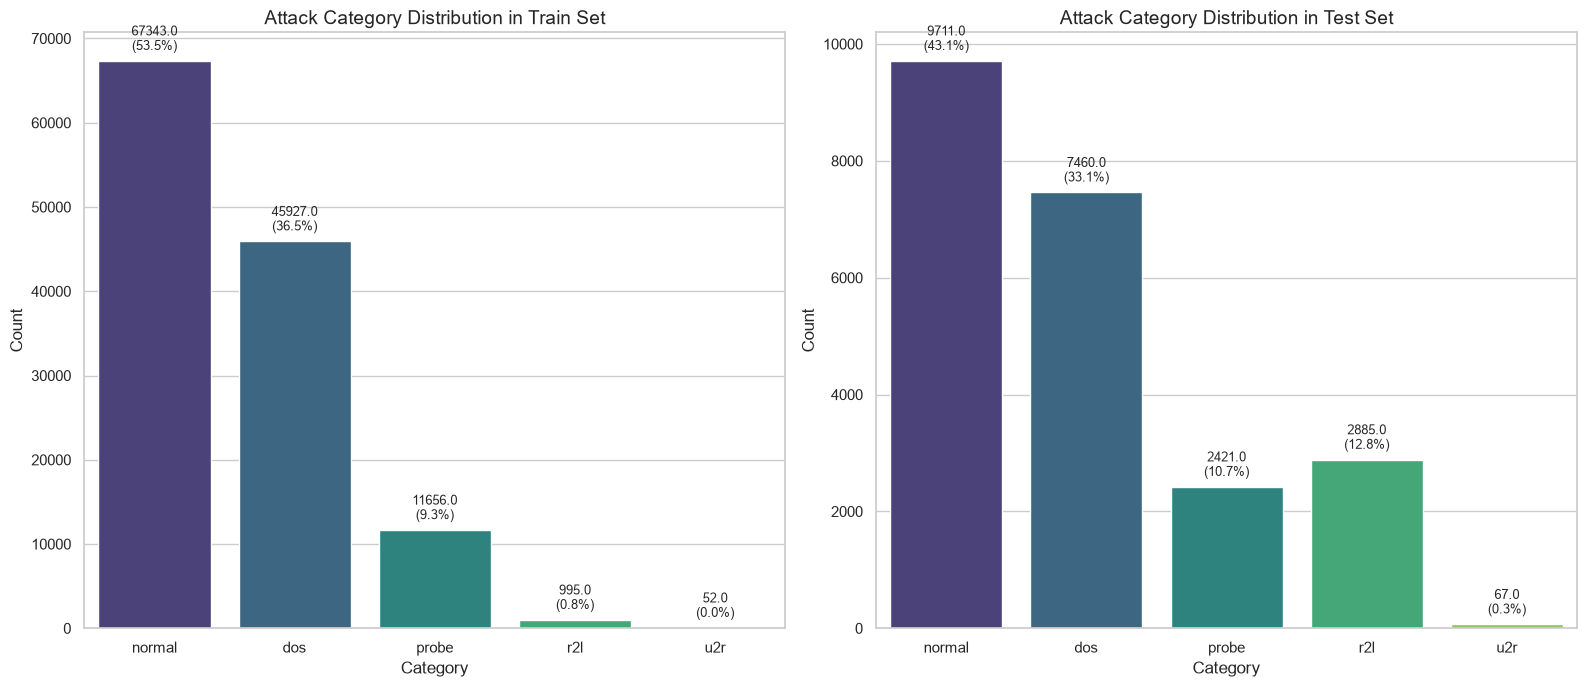

In [8]:
# Get counts and percentages
for name, df in [('Train', train_df), ('Test', test_df)]:
    counts = df['attack_category'].value_counts()
    pcts = df['attack_category'].value_counts(normalize=True) * 100
    print(f"\n=== {name} Attack Category Distribution ===")
    for idx in counts.index:
        print(f"{idx.upper()}: {counts[idx]} ({pcts[idx]:.2f}%)")

# Plotting the categories
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
order = ['normal', 'dos', 'probe', 'r2l', 'u2r']

for i, (name, df) in enumerate([('Train Set', train_df), ('Test Set', test_df)]):
    sns.countplot(x='attack_category', data=df, ax=axes[i], order=order, palette="viridis")
    axes[i].set_title(f"Attack Category Distribution in {name}")
    axes[i].set_xlabel("Category")
    axes[i].set_ylabel("Count")
    
    # Add labels
    for p in axes[i].patches:
        height = p.get_height()
        percentage = (height / len(df)) * 100
        axes[i].annotate(f'{height}\n({percentage:.1f}%)',
                    xy=(p.get_x() + p.get_width() / 2, height),
                    xytext=(0, 5),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


### 6. Protocol Types Analysis
We will analyze which transport-layer protocols are used in normal traffic versus different attack categories.


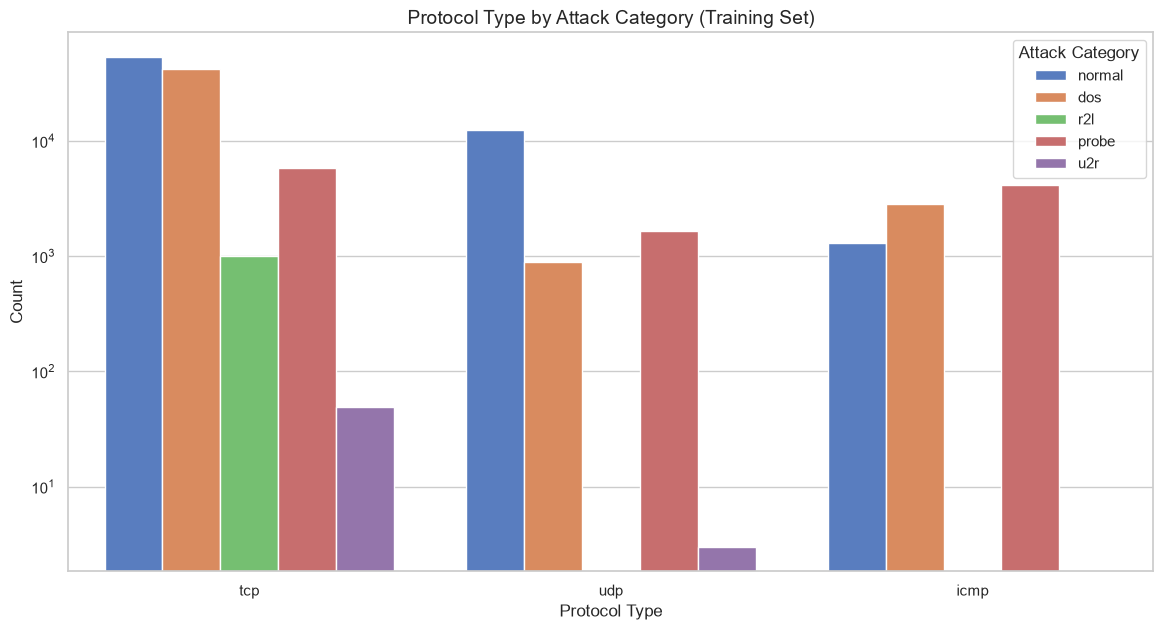

In [9]:
plt.figure(figsize=(14, 7))
sns.countplot(x='protocol_type', hue='attack_category', data=train_df, palette="muted")
plt.title("Protocol Type by Attack Category (Training Set)")
plt.xlabel("Protocol Type")
plt.ylabel("Count")
plt.yscale('log')  # Log scale for readability due to highly skewed distributions
plt.legend(title="Attack Category")
plt.show()


### 7. Specific Attack Type Breakdown
Let's see which specific attacks are most frequent in both sets. This is important to understand which vulnerabilities are most active, and whether the model will be exposed to novel attack types in the test set.


In [10]:
print("=== Top Specific Attacks in Train (Excluding normal) ===")
train_attacks_only = train_df[train_df['label'] != 'normal']
print(train_attacks_only['label'].value_counts().head(10))

print("\n=== Top Specific Attacks in Test (Excluding normal) ===")
test_attacks_only = test_df[test_df['label'] != 'normal']
print(test_attacks_only['label'].value_counts().head(10))

# Identify attacks present in test but NOT in train (zero-day/novel attacks)
train_unique_attacks = set(train_attacks_only['label'].unique())
test_unique_attacks = set(test_attacks_only['label'].unique())
novel_attacks = test_unique_attacks - train_unique_attacks

print(f"\nNumber of unique attack types in Train: {len(train_unique_attacks)}")
print(f"Number of unique attack types in Test: {len(test_unique_attacks)}")
print(f"Novel attacks present in Test but not in Train ({len(novel_attacks)} total):\n{novel_attacks}")


=== Top Specific Attacks in Train (Excluding normal) ===
label
neptune        41214
satan           3633
ipsweep         3599
portsweep       2931
smurf           2646
nmap            1493
back             956
teardrop         892
warezclient      890
pod              201
Name: count, dtype: int64

=== Top Specific Attacks in Test (Excluding normal) ===
label
neptune         4657
guess_passwd    1231
mscan            996
warezmaster      944
apache2          737
satan            735
processtable     685
smurf            665
back             359
snmpguess        331
Name: count, dtype: int64



Number of unique attack types in Train: 22
Number of unique attack types in Test: 37
Novel attacks present in Test but not in Train (17 total):
{'xsnoop', 'udpstorm', 'named', 'mailbomb', 'sendmail', 'saint', 'snmpguess', 'sqlattack', 'worm', 'httptunnel', 'apache2', 'xlock', 'xterm', 'mscan', 'processtable', 'ps', 'snmpgetattack'}


### Summary of Key Findings from EDA:
1. **Record Count**:
   - Training Set: 125,973 records, 43 columns.
   - Testing Set: 22,544 records, 43 columns.
2. **Missing Values**:
   - There are **zero missing values** in both the training and testing datasets.
3. **Normal vs. Attack Distribution**:
   - Training Set: **53.46% Normal** vs. **46.54% Attack** traffic. Relatively balanced.
   - Testing Set: **43.08% Normal** vs. **56.92% Attack** traffic. Contains a higher proportion of attack traffic.
4. **Attack Categories**:
   - **DoS** represents the largest attack category in both train and test.
   - **Probe** is the second most common.
   - **R2L** and **U2R** are much rarer, making them class-imbalanced, particularly U2R which accounts for less than 0.1% of the training set. Special attention (like sampling or class weighting) will be needed for these.
5. **Novel/Zero-day Attacks**:
   - The test set contains **17 novel attack types** that do not appear in the training set (e.g., `mscan`, `saint`, `httptunnel`, `mailbomb`, etc.). This represents a realistic evaluation scenario to test the generalizability of our threat detection model.
